# Klasifikasi DemogPairs Menggunakan Fitur ViT (Wajah, Emosi, dan Umur) & Gas

In [2]:
import numpy as np
import utilsv2 as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

joblib.parallel_backend('threading')

## Load Dataset

In [3]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [4]:
vggface_features = joblib.load('features/demogpairs_vit-face.pkl')
emotion_features = joblib.load('features/demogpairs_vit-emotion.pkl')
age_features = joblib.load('features/demogpairs_vit-age.pkl')
features = {}
for d in tqdm(data):
    key = d['image_path']
    features[key] = np.array(list(vggface_features[key]) + list(emotion_features[key]) + list(age_features[key]))
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

100%|██████████████████████████████████████████████████████████████████████████| 10800/10800 [00:01<00:00, 5657.93it/s]

Jumlah fitur per gambar: 2304


## Split Data

In [5]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [6]:
from sklearn.decomposition import PCA

grid_params = [
    {
        'scaler': [None, MinMaxScaler()],  # EN: scaling option / ID: opsi scaling
        'pca': [None, PCA(n_components=0.5), PCA(n_components=0.75)],  # EN: with and without PCA / ID: dengan dan tanpa PCA
        
        'classifier': [SVC()],  # EN: SVM model / ID: model SVM
        
        'classifier__C': [0.01, 0.1, 1, 10],  # EN: regularization / ID: regularisasi
        'classifier__kernel': ['rbf', 'poly', 'linear'],  # EN: kernel types / ID: jenis kernel
        
        'classifier__gamma': ['scale', 'auto'],  # EN: gamma / ID: gamma
        'classifier__degree': [2, 3],  # EN: degree / ID: derajat
        
        'classifier__tol': [1e-3],  # EN: tolerance / ID: toleransi
        'classifier__probability': [True],  # EN: probability / ID: probabilitas
    },
]

pipeline = Pipeline(steps=[
    ('scaler', None),  # EN: optional scaler / ID: scaler opsional
    ('pca', None),     # EN: optional PCA / ID: PCA opsional
    ('classifier', None)  # EN: classifier / ID: classifier
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.6),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

SVC: 288 kombinasi


## Klasifikasi

Mengevaluasi model: SVC
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


{'classifier': 'SVC', 'classifier__C': 10, 'classifier__degree': 2, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly', 'classifier__probability': True, 'classifier__tol': 0.001, 'pca': None, 'scaler': None}


Accuracy  : 0.937037037037037
Precision : 0.9371723737566707
Recall    : 0.937037037037037
F1 Score  : 0.9369428712161597
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       360
           1       0.92      0.95      0.94       360
           2       0.92      0.94      0.93       360
           3       0.95      0.97      0.96       360
           4       0.94      0.89      0.92       360
           5       0.93      0.93      0.93       360

    accuracy                           0.94      2160
   macro avg       0.94      0.94      0.94      2160
weighted avg       0.94      0.94      0.94      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9828703703703704,0.9549295774647887,0.9416666666666667,0.9482517482517483
White_Females,0.9782407407407407,0.924119241192412,0.9472222222222222,0.9355281207133059
Asian_Males,0.9777777777777777,0.9239130434782609,0.9444444444444444,0.9340659340659341
White_Males,0.987037037037037,0.953551912568306,0.9694444444444444,0.9614325068870524
Black_Females,0.9731481481481481,0.9415204678362573,0.8944444444444445,0.9173789173789174
Asian_Females,0.975,0.925,0.925,0.925


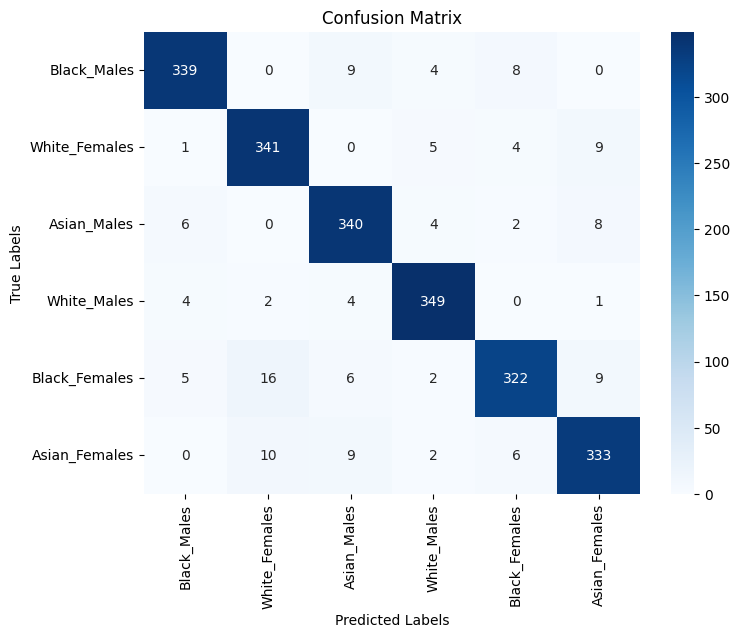

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
SVC,models/clf_demogpairs_svm_vit-face-emotion-age_SVC.pkl,"{'classifier': 'SVC', 'classifier__C': 10, 'classifier__degree': 2, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly', 'classifier__probability': True, 'classifier__tol': 0.001, 'pca': None, 'scaler': None}",0.937037037037037,0.9369428712161597,0.9371723737566707,0.937037037037037,288


In [7]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_svm_vit-face-emotion-age_',
    results_path='results/demogpairs_svm_vit-face-emotion-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [8]:
model, training_time = u.load_object('models/clf_demogpairs_svm_vit-face-emotion-age_SVC.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 42627.0,
 'days': 0,
 'hours': 11,
 'minutes': 50,
 'seconds': 27.0,
 'text': '0 hari 11 jam 50 menit 27.0 detik'}

In [9]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 269793.0,
 'days': 3,
 'hours': 2,
 'minutes': 56,
 'seconds': 33.0,
 'text': '3 hari 2 jam 56 menit 33.0 detik'}

In [10]:
def remove_keys(data, keys_to_remove, inplace=False):
    # EN: if not inplace, create a copy / ID: jika tidak inplace, buat salinan
    if not inplace:
        data = data.copy()
    
    # EN: loop through keys and remove safely / ID: loop key dan hapus dengan aman
    for key in keys_to_remove:
        data.pop(key, None)  # EN: avoid error if key not found / ID: aman jika key tidak ada
    
    return data

def dict_to_sentence(d):
    # EN: convert key-value pairs into readable parts / ID: ubah key-value jadi bagian kalimat
    parts = [f"{k}={v}" for k, v in d.items()]
    
    # EN: join all parts into one sentence / ID: gabungkan jadi satu kalimat
    sentence = ", ".join(parts)
    
    return sentence

fold_displays = []
for r in [remove_keys(r, ['No', 'F1 Score Mean', 'Precision Mean', 'Recall Mean', 'Train Time Mean']) for r in fold_results]:
    r['Params'] = dict_to_sentence(remove_keys(r['Params'], ['classifier'])).replace('classifier__', '')
    r['Mean'] = r['Accuracy Mean']
    del r['Accuracy Mean']
    fold_displays.append(r)
fold_displays = [{'No': idx + 1, **r} for idx, r in enumerate(sorted(fold_displays, key=lambda x: x['Mean'], reverse=True))]
_dtable = u.display_table(fold_displays, n_items=[3, 3, 3, 3], column_widths=['5%', '65%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean
1,"C=10, degree=2, gamma=scale, kernel=poly, probability=True, tol=0.001, pca=None, scaler=None",0.9404,0.93,0.9167,0.9201,0.9253,0.9265
2,"C=10, degree=3, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=None",0.9416,0.9288,0.9126,0.9207,0.9277,0.9263
3,"C=10, degree=2, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=None",0.9416,0.9288,0.9126,0.9207,0.9277,0.9263
...,...,...,...,...,...,...,...
96,"C=0.01, degree=3, gamma=scale, kernel=linear, probability=True, tol=0.001, pca=PCA, scaler=MinMaxScaler",0.9161,0.908,0.8935,0.9005,0.9045,0.9045
97,"C=0.01, degree=2, gamma=auto, kernel=linear, probability=True, tol=0.001, pca=PCA, scaler=MinMaxScaler",0.9161,0.908,0.8935,0.9005,0.9045,0.9045
98,"C=0.01, degree=2, gamma=scale, kernel=poly, probability=True, tol=0.001, pca=None, scaler=MinMaxScaler",0.9115,0.9062,0.8941,0.9074,0.9022,0.9043
...,...,...,...,...,...,...,...
191,"C=0.1, degree=3, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=MinMaxScaler",0.8912,0.8762,0.8698,0.8796,0.8796,0.8793
192,"C=0.1, degree=2, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=None",0.8889,0.8779,0.8698,0.8796,0.8762,0.8785
